## Meter Maintenance Notebook

This notebook is a **review and maintenance tool** for the running broken meter list. It is not the normal Harvest kWh processing pipeline.

Use it when a meter needs closer inspection or when an existing broken meter record may need to be **updated**, **removed**, or **added**.

<span style="color:royalblue">What this notebook does:</span>
1. Loads raw 15 minute cumulative kWh readings.
2. Keeps meters whose `end_use` is exactly `main` or `submeter`.
3. Excludes the configured PV-building main meters and Student Health.
4. Loads the current broken meter list and supporting review files. 
5. Builds a list of meters to review.
6. Creates a PDF showing raw readings and all relevant issue overlays.
7. Creates or refreshes a maintenance update log.
8. Applies only approved log actions to a **reviewed copy** of the broken meter list.
9. Creates a second PDF preview of the approved changes.
10. Commits the reviewed copy to the source file only after an explicit final switch is set to `True`.



<span style="color:royalblue">Important safety rule:</span>

Running all cells does **not** overwrite `running_list_broken_meters.csv` while: 
```python
commit_reviewed_changes_to_source = False 
```
<span style="color:royalblue">**Keep setting == `False` until the approved change preview PDF has been reviewed**</span>

### Files used by this notebook

<span style="color:royalblue">Inputs:</span>
- `running_list_broken_meters.csv` = source of truth for broken-meter periods.
- `meter_info.csv` = identifies `main` and `submeter` meters.
- Raw Harvest kWh CSV = provides meter readings for review plots.

<span style="color:royalblue">Main pipeline files: </span>
- `removed_special_meter_data.csv` = raw readings removed by approved corrections.
- `special_meter_candidates.csv` = unresolved detected meter issues.
- `special_meters_corrections_master_sheet.csv` = combined correction records used for reference.

<span style="color:royalblue">Notebook outputs: </span>
- `broken_meter_update_log.csv` = proposed `update`, `remove`, and `add` actions.
- `running_list_broken_meters_reviewed_copy.csv` = preview of the updated broken-meter list.
- `maintenance_review_selected_meters.pdf` = review plots with issue overlays.
- `maintenance_approved_changes_preview.pdf` = final preview before approved changes are committed.

In [1]:
# Future cleanup ideas only; these comments do not affect execution.

# TODO: add __file__
#TODO: change to load from server
# TODO: change to server paths if running on server, make be all of its meter data or a subset
# var_file = input_dir + "harvest_kwh_15min_" + "250723-260713.csv" #"250723-251017.csv"


# for update log
# TODO: status check for update actions
# TODO: remove reason column?

# important:
# TODO: have it change the updated data date column when applying changes

### 1. Parameters

In [ ]:
############ CHANGE PARAMETERS AS NEEDED #############

# review every meter from the broken source file that has a status in BROKEN_STATUS_VALUES
review_all_broken_status_meters = True

# manual review list, this is used only when review_all_broken_status_meters = False
# leave empty if using automatic broken meter selection
meters_to_review = []

# optional plot zoom, leave both as None to display the full raw-data range.
zoom_start = None  # e.g. "2025-08-01 00:00:00"
zoom_end = None     # e.g. "2025-10-01 00:00:00"

# if True, refresh the update log rows for the selected meters
# if review_all_broken_status_meters = True and meters_to_review = [], 
# then this will refresh the update log for all meters with a broken status
refresh_update_log_for_selected_meters = True 

# set to True only after broken_meter_update_log.csv has been
# reviewed and the desired rows marked approved = 1
update_log_reviewed = False

######################################################

In [3]:
# Data Directories
input_dir = "../data/extracts/"
output_dir = "../data/outputs/"
maintenance_dir = "../data/outputs/maintenance/"


# Raw cumulative kWh readings used for visual review
# Update the date suffix
var_file = input_dir + "harvest_kwh_15min_" + "250723-260713.csv" #"250723-251017.csv"

# Main pipeline source/review files
meter_issues_candidates_file = input_dir + "special_meter_candidates.csv"
broken_meters_file = input_dir + "running_list_broken_meters.csv"
meter_info_file = input_dir + "meter_info.csv"

# Main pipeline generated files
meter_corrections_file = output_dir + "special_meters_corrections_master_sheet.csv"
removed_special_meter_data_file = output_dir + "removed_special_meter_data.csv"

# Maintenance files
broken_meter_update_log_file = maintenance_dir + "broken_meter_update_log.csv"
broken_meter_reviewed_copy_file = maintenance_dir + "running_list_broken_meters_reviewed_copy.csv"
maintenance_plot_file = maintenance_dir + "maintenance_review_selected_meters.pdf" #plot_dir + "maintenance_review_selected_meters.pdf"

######################################################
# Exclude: Meters of buildings equipped with PV and Student Health
meters_with_pv = [
    'bachman_hall_main',
    'campus_ctr_main',
    'dance_bldg_main',
    'gartley_hall_main',
    'warrior_rec_ctr_main'
]
meters_excluded = meters_with_pv + ['student_health_main']  # student_health data is in vitality_v5


1. **Import dependencies**
2. **Load and reshape raw data**
3. **Select main meters and submeters**
4. **Build the review list**
5. **Load broken, candidate, master correction, and removed reading files**
6. **Generate initial review plots**
7. **Prepare the editable update log**
8. **Apply approved actions to a reviewed copy**
9. **Generate approved change preview plots**
10. **Optionally commit the reviewed copy to the source file**
11. **Rerun the main pipeline**

### 2. Imports

In [4]:
import os, sys
import importlib
import pandas as pd

sys.path.append(os.path.abspath('..'))
import modules.data_clean_TEST as dc # import self-defined module
importlib.reload(dc)

<module 'modules.data_clean_TEST' from '/Users/cassiehuber/Documents/GitHub/harvest_kwh_prep/modules/data_clean_TEST.py'>

### 3. Load and Reshape Meter Data

In [5]:
# Load raw interval data
raw_df = pd.read_csv(var_file, low_memory=False)
raw_df["datetime"] = pd.to_datetime(raw_df["datetime"])
raw_df = raw_df.dropna(subset=["datetime"]).copy()

# Pivot to wide meter dataframe with every meter as one column (reshape data)
pivoted_df = raw_df.pivot(
    index="datetime",
    columns="meter_name",
    values="meter_reading",
).reset_index()

# Fill missing timestamps to ensure continuous time series
full_df = dc.fill_missing_timestamps(pivoted_df, "15min")

######################################################
# Keep only exact main meters and submeters from meter_info.csv
# Remove excluded meters (meters with PV)

data, meter_type_by_meter, selected_meter_info = (
    dc.select_meter_types_from_info(
        full_df,
        meter_info_file,
        allowed_end_uses=("main", "submeter"),
        excluded_meters=meters_excluded,
    )
)

######################################################

# Load broken meter source file
broken_source_df = dc.load_broken_meter_workbook(broken_meters_file)

# Build review meter list automatically from broken source statuses
data_cols_norm = {str(col).strip().lower() for col in data.columns}

all_broken_status_meters = sorted(
    broken_source_df["meter_name"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
    .unique()
    .tolist()
)

meters_not_in_data = sorted(
    [meter for meter in all_broken_status_meters if meter not in data_cols_norm]
)

if review_all_broken_status_meters:
    meters_to_review = sorted(
        [meter for meter in all_broken_status_meters if meter in data_cols_norm]
    )

print("all broken status meters from source file:", len(all_broken_status_meters))
print("broken status main/submeters not found in selected data:", len(meters_not_in_data))

if meters_not_in_data:
    print("not in selected main/submeter data:")
    print(meters_not_in_data)

######################################################

# Load candidate workbook
candidate_df = dc.load_existing_candidates(meter_issues_candidates_file, low_memory=False)

######################################################

# Load generated master corrections file
master_corrections_df = pd.read_csv(meter_corrections_file, low_memory=False)

######################################################

# Load removed raw data captured inside remove/broken windows
removed_df = pd.read_csv(removed_special_meter_data_file, low_memory=False)
for col in ["datetime", "correction_start", "correction_end"]:
    if col in removed_df.columns:
        removed_df[col] = pd.to_datetime(removed_df[col], errors="coerce")

######################################################

# Summary of loaded data
print("\nraw_df shape:", raw_df.shape)
print("selected maintenance data shape:", data.shape)
print("broken_source_df rows:", len(broken_source_df))
print("removed_df rows:", len(removed_df))


Selected 91 meters: 74 main, 17 submeter.
all broken status meters from source file: 34
broken status main/submeters not found in selected data: 20
not in selected main/submeter data:
['campus_center_ac_main', 'ching_complex_main', 'hale_noelani_all_towers_main', 'hale_noelani_tower_a_b', 'hale_noelani_tower_b', 'hale_noelani_tower_c', 'hale_noelani_tower_c_d', 'hale_noelani_tower_e', 'hig_substation_1_main', 'hig_substation_2_main', 'hig_substation_3_main', 'it_center_main', 'korean_studies_main', 'law_clinic_main', 'law_school_ac_main', 'pope_lab_main', 'quad_chiller_plant_main', 'saunders_hall_main_a', 'sinclair_lib_main', 'softball_tennis_main']

raw_df shape: (2049522, 3)
selected maintenance data shape: (34085, 91)
broken_source_df rows: 35
removed_df rows: 104306


/var/folders/xq/86ckk2090mg78b7hxm1ftptr0000gn/T/ipykernel_95638/3482255091.py:76: DtypeWarning: Columns (0: correction_end) have mixed types. Specify dtype option on import or set low_memory=False.
  removed_df = pd.read_csv(removed_special_meter_data_file)


### 4. Meter Review Plots
- The title identifies the meter classification, for example `[main]` or `[submeter]`.
- Use `zoom_start` and `zoom_end` in the settings cell to inspect a smaller time range. The PDF is still saved when `show_plots=False`; that option only controls inline notebook display.

#### Plot legend
- blue line = raw meter readings
- orange points = raw readings captured in `removed_special_meter_data.csv`
- red spans = broken intervals from `running_list_broken_meters.csv`
- blue spans = candidate issue intervals from `special_meter_candidates.csv`
- black dashed line = a detected restart or drop event
- purple spans = visual overlap between trasnparent red and blue spans

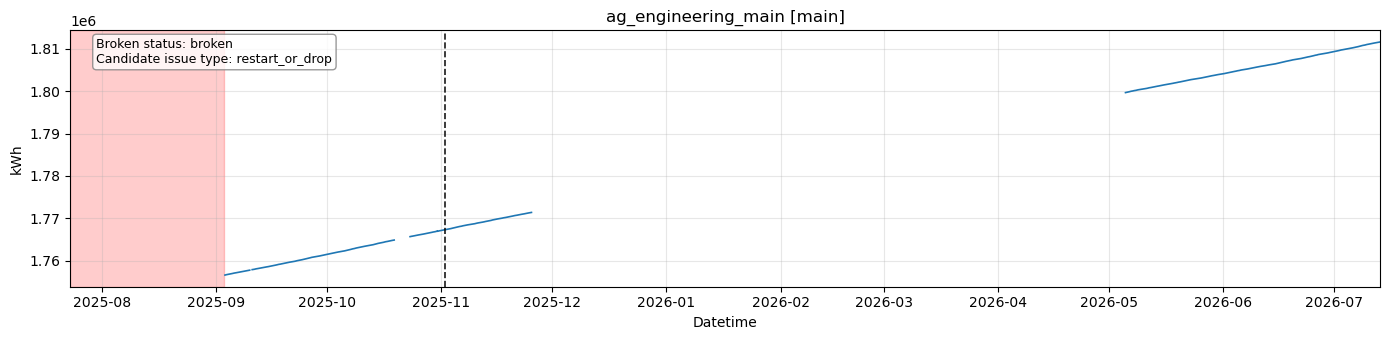

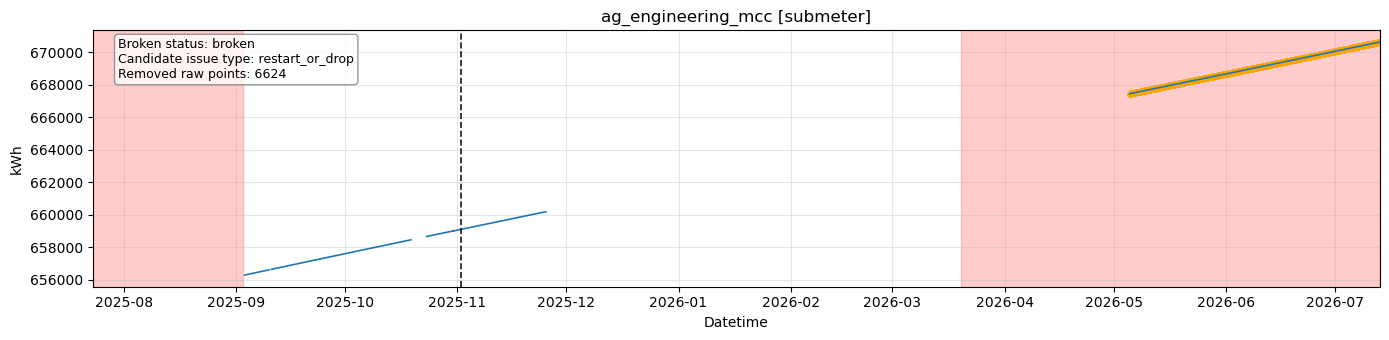

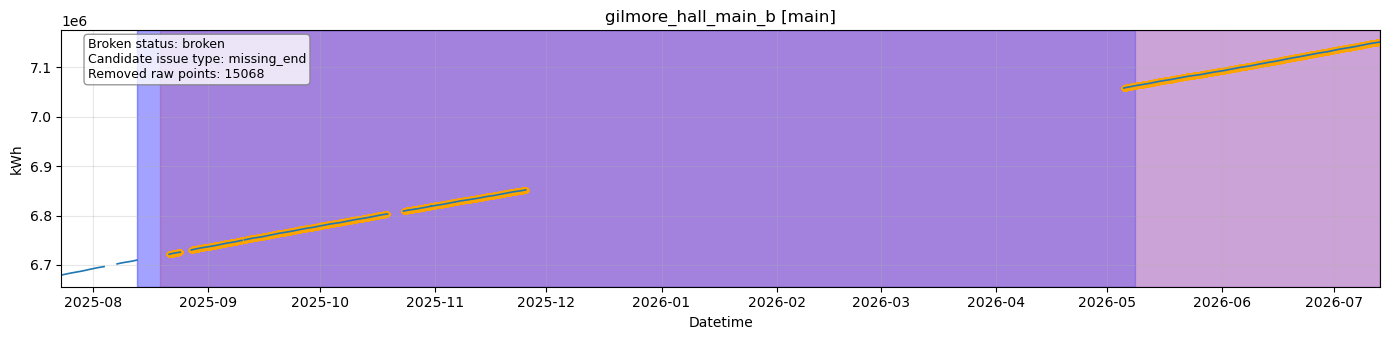

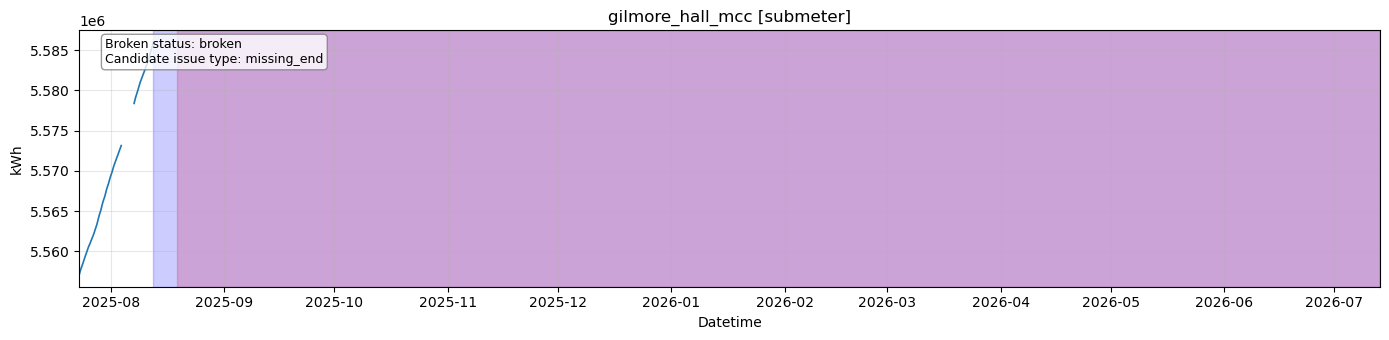

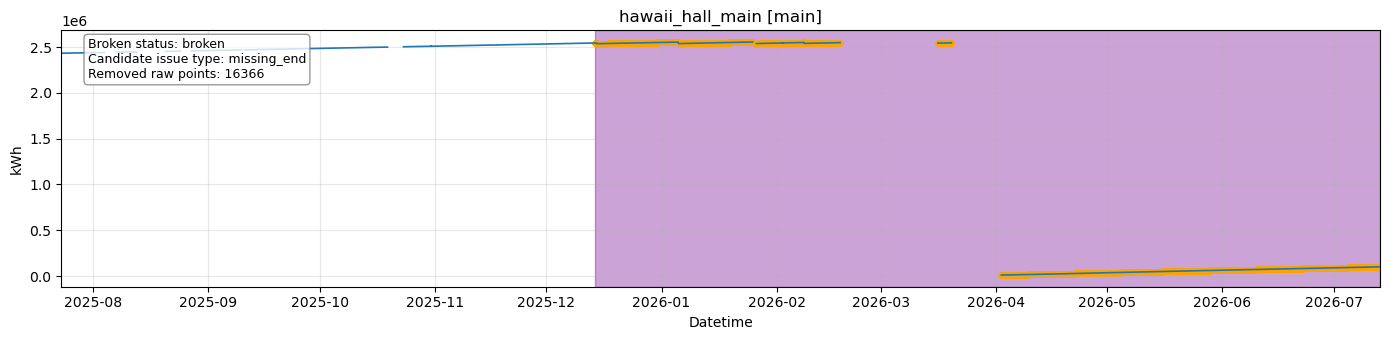

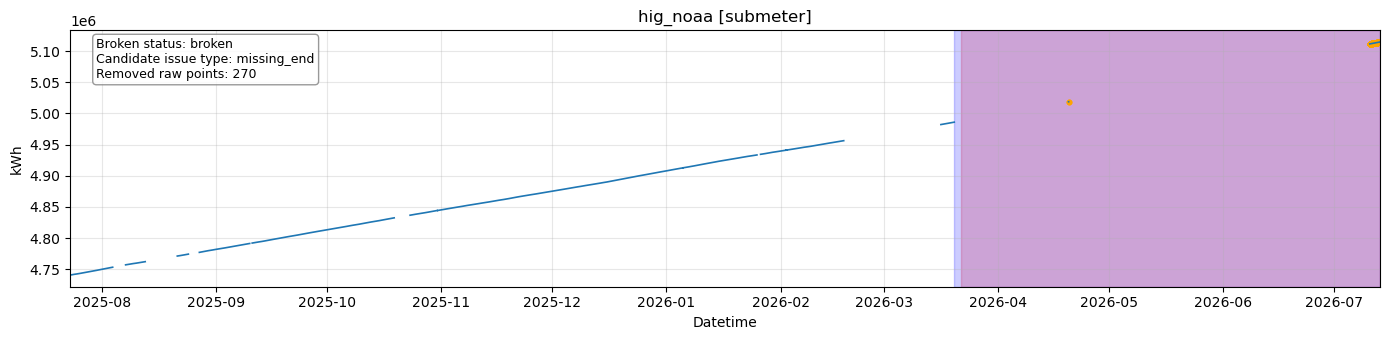

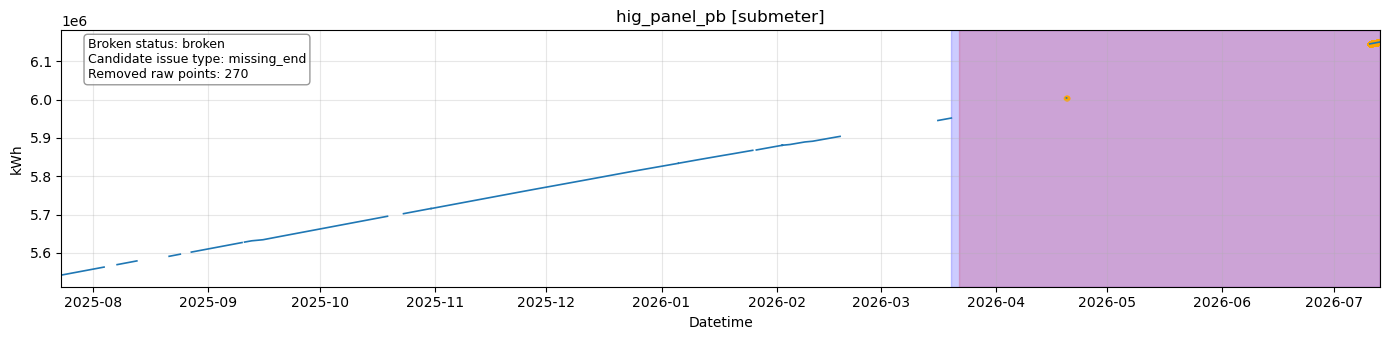

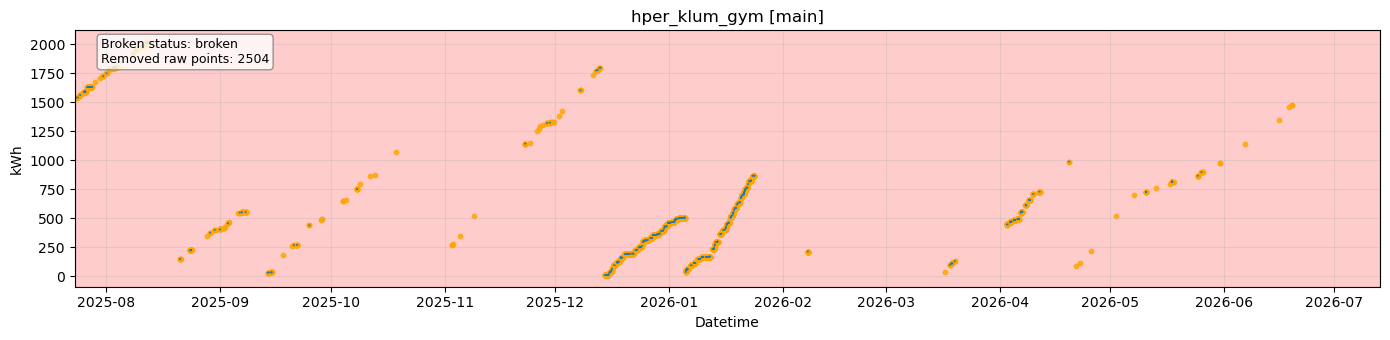

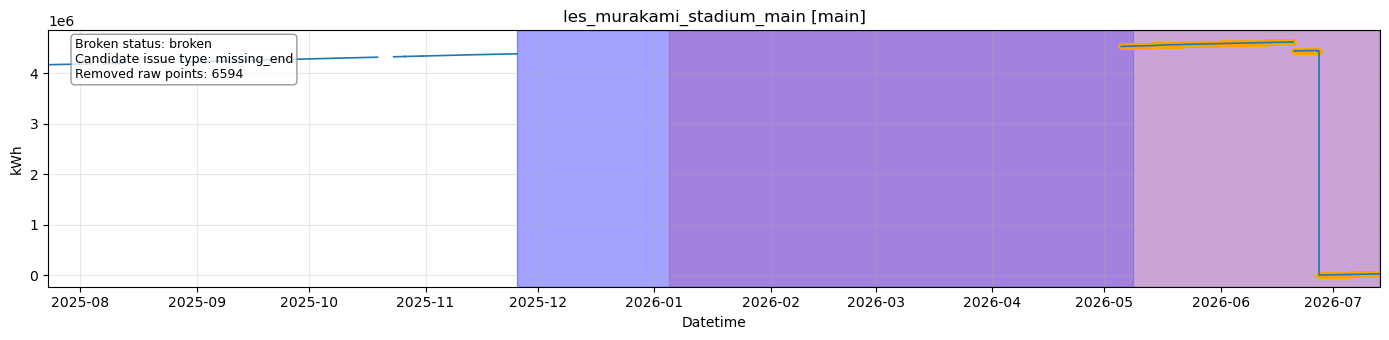

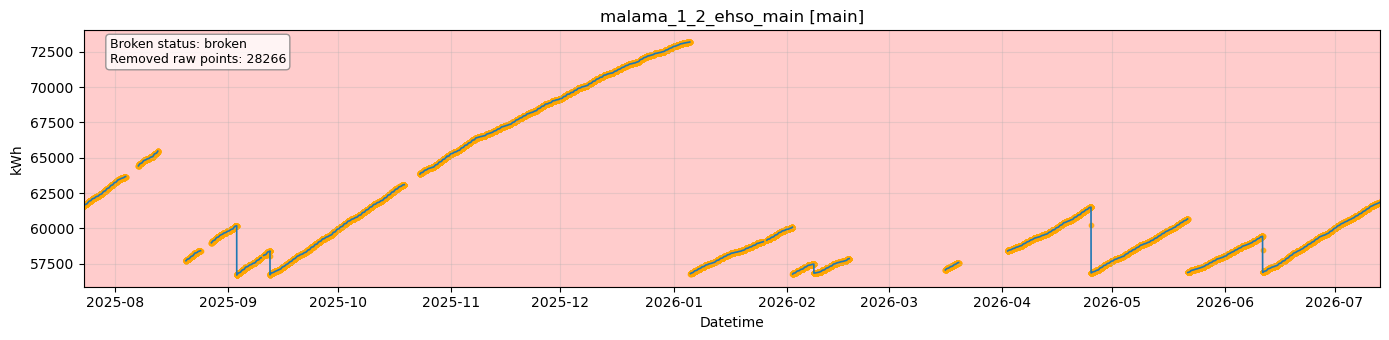

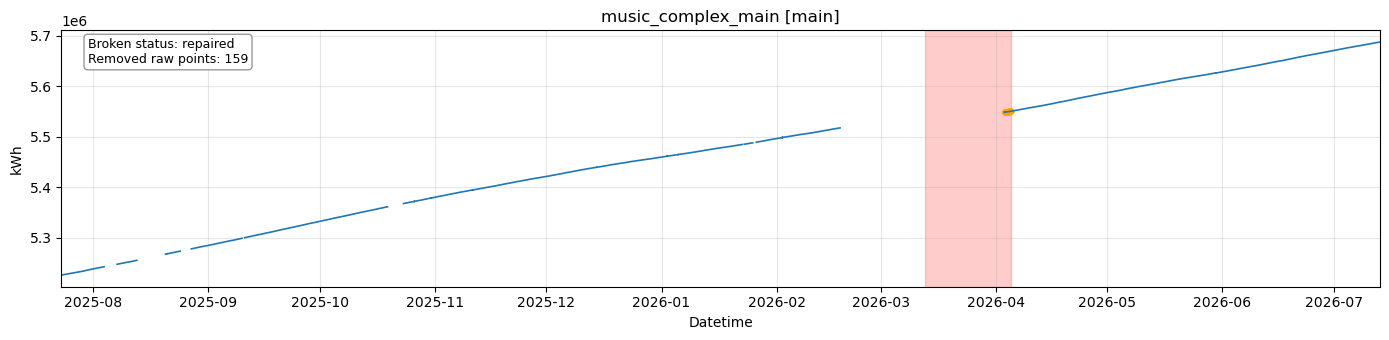

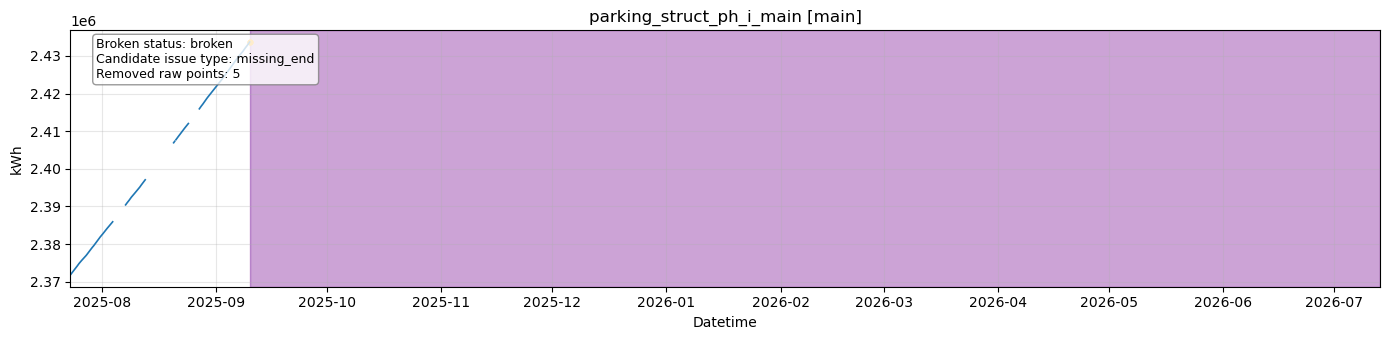

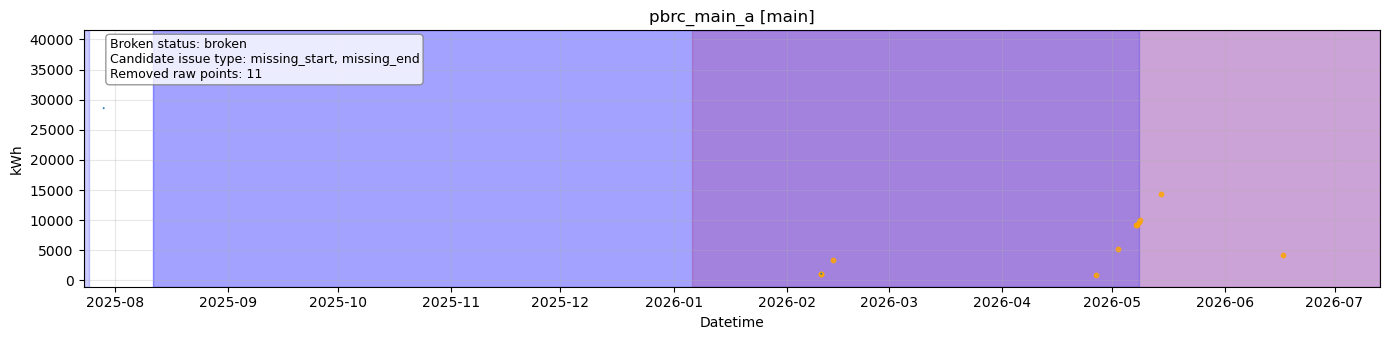

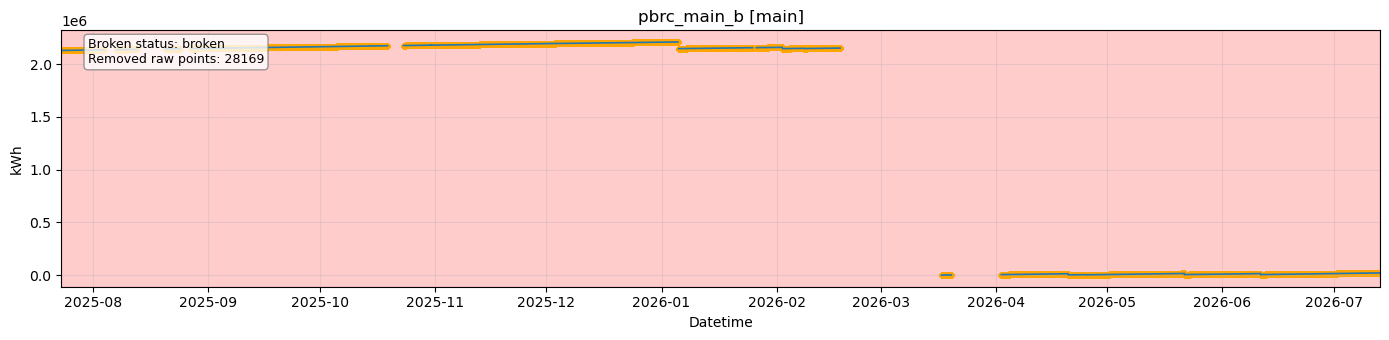

Saved maintenance review plots to ../data/outputs/maintenance/maintenance_review_selected_meters.pdf


In [6]:
# Generate one PDF page per selected meter, preceded by a standalone legend page.
maintenance_saved_count = dc.plot_meter_maintenance_review_pdf(
    data=data,
    meters_to_review=meters_to_review,
    broken_df=broken_source_df,
    candidate_df=candidate_df,
    removed_df=removed_df,
    plot_file=maintenance_plot_file,
    meter_type_map=meter_type_by_meter,
    zoom_start=zoom_start,
    zoom_end=zoom_end,
    ylabel="kWh",
    show_plots=True, # can be set to False if running on server and not wanting to display plots
)

### 5. Create or Refresh Maintenance Update Log

- The update log is the editable instruction sheet for proposed maintenance changes. This step does **not** change the broken meter source file.
- When refreshing selected meters, their log rows are rebuilt from the current source file. This helps prevent decisions from being based on stale source values. Rows for meters not selected in this run are preserved.

<span style="color:royalblue">Column guide:</span>
| Column | Meaning |
|---|---|
| `meter_name` | Meter affected by the proposed action |
| `source_start_date` / `source_end_date` | Current dates in the broken-meter source row |
| `source_status` | Current source status |
| `source_description` | Current source description |
| `action` | `update`, `remove`, or `add` |
| `new_start_date` / `new_end_date` | Proposed replacement dates |
| `new_status` | Proposed replacement status |
| `new_description` | Proposed replacement description |
| `reason` | Human readable reason for the change |
| `approved` | Set to `1` only when the row is ready to be applied |

In [12]:
# Create the log if it does not exist, or refresh rows for this run's selected
# meters when refresh_update_log_for_selected_meters is True
update_log_df = dc.prepare_broken_meter_update_log(
    update_log_file=broken_meter_update_log_file,
    broken_source_df=broken_source_df,
    meters_to_review=meters_to_review,
    refresh_selected_meters=refresh_update_log_for_selected_meters,
)

# Display only the currently selected meters when possible
print("Update log rows for the selected meters:")
display(
    update_log_df[
        update_log_df["meter_name"].isin(
            [m.strip().lower() for m in meters_to_review]
        )
    ] if meters_to_review else update_log_df.head(2)
)

,meter_name,source_start_date,source_end_date,source_status,source_description,action,new_start_date,new_end_date,new_status,new_description,reason,approved
0,ag_engineering_main,2025-02-19 00:00:00,2025-09-03 00:00:00,broken,3/16/26 vernon says it needs to be reprogrammed,NaN,NaN,NaN,NaN,NaN,NaN,0
1,ag_engineering_mcc,2026-03-20 00:00:00,NaN,broken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,ag_engineering_mcc,2025-02-19 00:00:00,2025-09-03 00:00:00,broken,repaired,NaN,NaN,NaN,NaN,NaN,NaN,0
3,gilmore_hall_main_b,2025-08-19 00:00:00,NaN,broken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,gilmore_hall_mcc,2025-08-19 00:00:00,NaN,broken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,hawaii_hall_main,2025-12-14 00:00:00,NaN,broken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6,hig_noaa,2026-03-22 00:00:00,NaN,broken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
7,hig_panel_pb,2026-03-22 00:00:00,NaN,broken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
8,hper_klum_gym,2023-11-15 00:00:00,NaN,broken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9,les_murakami_stadium_main,2026-01-05 00:00:00,NaN,broken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


### 6. Edit and Review Update log 
(`broken_meter_update_log.csv`)

- Open the CSV and complete the proposed action fields. Leave `approved = 0` while a decision is still being reviewed or to nothing to the row
- `update` = modify an existing broken meter row
- `remove` = delete an existing broken meter row
- `add` = create a new broken meter row


Use `approved = 1` only after confirming:
- the correct meter is identified;
- the source row shown in the log is the row that should be changed;
- the proposed dates and status match the plots;
- the action type is correct;
- the reason is understandable to a future reviewer.

In [17]:
if not update_log_reviewed:
    raise SystemExit(
        "Execution stopped because update_log_reviewed = False. "
        "Review broken_meter_update_log.csv, mark the desired rows approved = 1, "
        "then set `update_log_reviewed = True` and re-run the notebook."
    )

NameError: name 'update_log_reviewed' is not defined

### 7. Apply Approved Update Log Changes to Review **Copy**
- only rows with approved == 1 are applied
- it always writes **`running_list_broken_meters_reviewed_copy.csv`** for final review


Notes:
`update`
- finds exactly one matching source row in running_list_broken_meters.csv
- changes only the new_* fields you filled in
- blank new_* fields keep the original source values
- `remove`
finds exactly one matching source row
removes it from the reviewed output
- `add`
creates a new row using meter_name plus the new_* fields
requires new_status
prevents adding an exact duplicate row



In [9]:
# Apply approved actions and save the safe reviewed copy
reviewed_broken_df, applied_change_log_df = (
    dc.apply_broken_meter_update_actions(
        broken_source_df=broken_source_df,
        update_log_df=update_log_df,
        reviewed_copy_file=broken_meter_reviewed_copy_file,
    )
)

if applied_change_log_df.empty:
    print("No approved update log rows to apply.")
else:
    print("Approved update log rows applied to reviewed copy of broken meters source file:")
    display(applied_change_log_df)

    print("First 20 rows of the reviewed copy of broken meters source file:")
    display(reviewed_broken_df.head(20))

Reviewed broken meter copy saved to ../data/outputs/maintenance/running_list_broken_meters_reviewed_copy.csv
No approved update log rows to apply.


### 8. Preview approved changes visually
- This PDF shows every meter affected by an approved update log action
- Plots of all meters with approved actions and new_*, even if write_changes_to_source_file = False

In [10]:
# Post maintenance visual check
# Shows raw readings with the newly reviewed broken meter intervals.
# Candidate and removed data overlays are intentionally omitted because
# they have not yet been regenerated by the main pipeline.

proposed_update_plot_file = (maintenance_dir + "maintenance_approved_changes_preview.pdf")

saved_count = 0

if applied_change_log_df.empty:
    print(
        "No approved maintenance changes were applied, "
        "so no post update plots were created."
    )
else:
    # A meter can have multiple approved actions, unique() ensures it receives
    # only one preview page
    changed_meters = sorted(
        applied_change_log_df["meter_name"]
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
        .unique()
        .tolist()
    )

    # The preview uses the proposed reviewed broken meter dataframe, not the
    # original source dataframe
    saved_count = dc.plot_approved_maintenance_preview_pdf(
        data=data,
        changed_meters=changed_meters,
        reviewed_broken_df=reviewed_broken_df,
        plot_file=proposed_update_plot_file,
        meter_type_map=meter_type_by_meter,
        zoom_start=zoom_start,
        zoom_end=zoom_end,
        ylabel="kWh",
        show_plots=True # can be set to False if running on server and not wanting to display plots,
    )


No approved maintenance changes were applied, so no post update plots were created.


### 9. Final Commit Reviewed Changes to **Source File**
(`running_list_broken_meters_reviewed.csv`)

COMMIT PROCEDURE:
1. Review broken_meter_update_log.csv
2. Run the approved-action cells
3. Review maintenance_approved_changes_preview.pdf
4. Confirm running_list_broken_meters_reviewed_copy.csv
5. Change the switch below to True
6. Run ONLY the cell bellow.

In [11]:
# COMMIT REVIEWED CHANGES TO THE SOURCE FILE
#
# Leave False while reviewing the preview graphs
# After reviewing the graphs, change to True and run only
# this cell
#
# COMMIT PROCEDURE:
# 1. Review broken_meter_update_log.csv
# 2. Run the approved-action cells
# 3. Review maintenance_approved_changes_preview.pdf
# 4. Confirm running_list_broken_meters_reviewed_copy.csv
# 5. Change the switch below to True
# 6. Run ONLY this cell
######################################################

commit_reviewed_changes_to_source = False # remember to keep false before running all cells

######################################################

if not commit_reviewed_changes_to_source:
    print(
        "Preview only. Source broken meter file was not changed.\n"
        "Review the proposed change graph, then set "
        "commit_reviewed_changes_to_source = True and rerun this cell."
    )

elif applied_change_log_df.empty:
    print(
        "No approved update log actions were found. "
        "Source file was not changed."
    )

else:
    # This is the only source file overwrite
    reviewed_broken_df.to_csv(
        broken_meters_file,
        index=False,
        date_format="%Y-%m-%d %H:%M:%S",
    )

    print(
        "Approved maintenance changes committed to source file:\n"
        f"{broken_meters_file}"
    )
    print(
        "Now rerun 1.kwh_end_points so corrections, removed data, "
        "candidates, and final plots regenerate."
    )

if saved_count:
    print(
        f"Review the {saved_count} plots in {proposed_update_plot_file}"
        "before committing reviewed_broken_df to the source broken meter file."
    )

Preview only. Source broken meter file was not changed.
Review the proposed change graph, then set commit_reviewed_changes_to_source = True and rerun this cell.


### 10. Required follow up after committing changes

After `running_list_broken_meters.csv` has been updated, rerun the main `1.kwh_end_points` notebook

- the master correction sheet
- removed special meter data
- unresolved candidate records
- review special meter plots
- corrected all-meter plots
- downstream cleaned and annual meter outputs

Until the main pipeline is rerun, those generated files may still describe the previous broken meter configuration